# Data Preprocessing

##### Import Necessary Modules

In [18]:
import pandas as pd
import sqlite3
import os 
import matplotlib.pyplot as plt
import seaborn as sns

##### Connect to database 

In [46]:
conn = sqlite3.connect('D:\jai\Python-Workspace\Credit-Path-AI\database\creditpathai.db')

##### Read data in dataframes

In [5]:
loan_df = pd.read_sql('SELECT * FROM loans', conn)
loan_df.head()

,loanId,memberId,date,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,loanStatus
0,1888978,2305095,12/10/2014,debtconsolidation,0.0,25190.0,60 months,6.25,490,E3,Current
1,1299695,2610493,9/15/2014,debtconsolidation,0.0,21189.0,60 months,10.49,455,B3,Current
2,1875016,2491679,9/11/2014,debtconsolidation,0.0,29908.0,60 months,9.11,622,B2,Current
3,1440478,2092798,4/22/2016,homeimprovement,0.0,13053.0,48 months,11.89,343,B3,Current
4,1124634,2633077,2/3/2016,debtconsolidation,0.0,24613.0,60 months,15.13,587,A3,Current


In [6]:
borrower_df = pd.read_sql('SELECT * FROM borrowers', conn)
borrower_df.head()

,memberId,residentialState,yearsEmployment,homeOwnership,annualIncome,incomeVerified,dtiRatio,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,numOpenCreditLines1Year,revolvingBalance,revolvingUtilizationRate,numDerogatoryRec,numDelinquency2Years,numChargeoff1year,numInquiries6Mon
0,2305095,NM,10+ years,rent,56471,1,16.80,6,11,9.0,6,14301,49.02,0,19,10,0
1,2610493,WA,2-5 years,rent,55038,0,19.99,22,8,7.0,4,18262,72.40,1,0,0,0
2,2491679,MS,< 1 year,rent,56610,1,14.33,5,8,5.0,5,10799,66.27,0,1,1,0
3,2092798,TX,6-9 years,own,54887,1,14.80,12,14,7.0,3,15272,61.05,1,0,0,3
4,2633077,MA,2-5 years,rent,53522,1,10.14,4,21,19.0,10,19316,56.39,2,14,7,1


##### Merge the dataframes into single data

In [8]:
df = pd.merge(loan_df, borrower_df, on="memberId", how="left")

In [9]:
df.head()

,loanId,memberId,date,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,...,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,numOpenCreditLines1Year,revolvingBalance,revolvingUtilizationRate,numDerogatoryRec,numDelinquency2Years,numChargeoff1year,numInquiries6Mon
0,1888978,2305095,12/10/2014,debtconsolidation,0.0,25190.0,60 months,6.25,490,E3,...,6,11,9.0,6,14301,49.02,0,19,10,0
1,1299695,2610493,9/15/2014,debtconsolidation,0.0,21189.0,60 months,10.49,455,B3,...,22,8,7.0,4,18262,72.40,1,0,0,0
2,1875016,2491679,9/11/2014,debtconsolidation,0.0,29908.0,60 months,9.11,622,B2,...,5,8,5.0,5,10799,66.27,0,1,1,0
3,1440478,2092798,4/22/2016,homeimprovement,0.0,13053.0,48 months,11.89,343,B3,...,12,14,7.0,3,15272,61.05,1,0,0,3
4,1124634,2633077,2/3/2016,debtconsolidation,0.0,24613.0,60 months,15.13,587,A3,...,4,21,19.0,10,19316,56.39,2,14,7,1


In [12]:
df.shape

(100000, 27)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   loanId                    100000 non-null  int64  
 1   memberId                  100000 non-null  int64  
 2   date                      100000 non-null  object 
 3   purpose                   100000 non-null  object 
 4   isJointApplication        99029 non-null   float64
 5   loanAmount                98994 non-null   float64
 6   term                      98929 non-null   object 
 7   interestRate              100000 non-null  float64
 8   monthlyPayment            100000 non-null  int64  
 9   grade                     100000 non-null  object 
 10  loanStatus                100000 non-null  object 
 11  residentialState          100000 non-null  object 
 12  yearsEmployment           100000 non-null  object 
 13  homeOwnership             100000 non-null  ob

##### Imputing NULL Values

In [13]:
df.isna().sum()

loanId                         0
memberId                       0
date                           0
purpose                        0
isJointApplication           971
loanAmount                  1006
term                        1071
interestRate                   0
monthlyPayment                 0
grade                          0
loanStatus                     0
residentialState               0
yearsEmployment                0
homeOwnership                  0
annualIncome                   0
incomeVerified                 0
dtiRatio                       0
lengthCreditHistory            0
numTotalCreditLines            0
numOpenCreditLines           967
numOpenCreditLines1Year        0
revolvingBalance               0
revolvingUtilizationRate       0
numDerogatoryRec               0
numDelinquency2Years           0
numChargeoff1year              0
numInquiries6Mon               0
dtype: int64

isJoinApplication, loanAmount, term, numOpenCreditLines1Year are columns containing NaN values

Imputation of isJointApplication

In [15]:
df['isJointApplication'].unique()

array([ 0.,  1., nan])

In [16]:
mode = df['isJointApplication'].mode()[0]
df['isJointApplication'].fillna(mode, inplace=True)
df['isJointApplication'].unique()

C:\Users\Govin\AppData\Local\Temp\ipykernel_3624\609195269.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['isJointApplication'].fillna(mode, inplace=True)


array([0., 1.])

In [17]:
df['isJointApplication'].value_counts()

isJointApplication
0.0    95032
1.0     4968
Name: count, dtype: int64

Imputation of loanAmount <br>
loanAmount is continuous so we need to check whether mean is suitable or media is suitable <br>
For this we have to check if there are any outliers in loanAmount

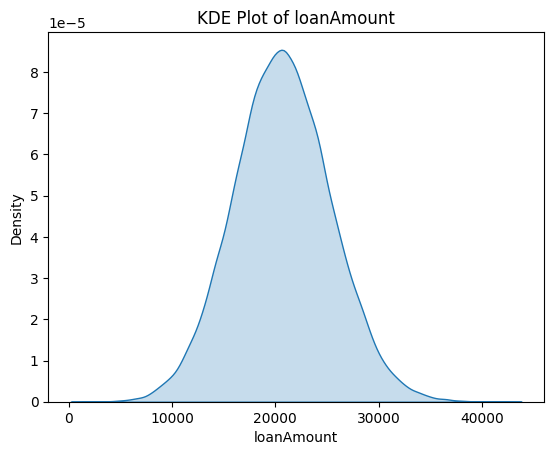

In [23]:
sns.kdeplot(data=df, x="loanAmount", fill=True)

plt.title("KDE Plot of loanAmount")
plt.show()

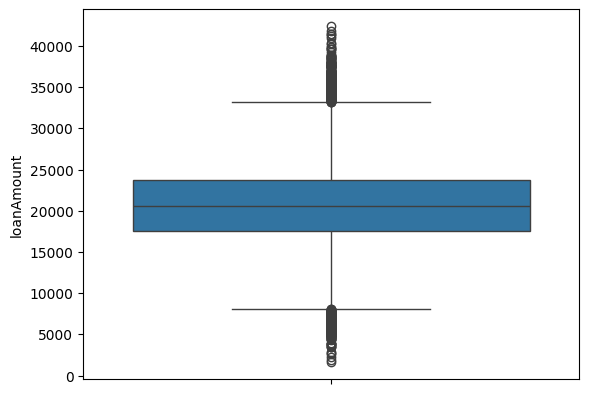

In [24]:
sns.boxplot(y=df['loanAmount'])
plt.show()

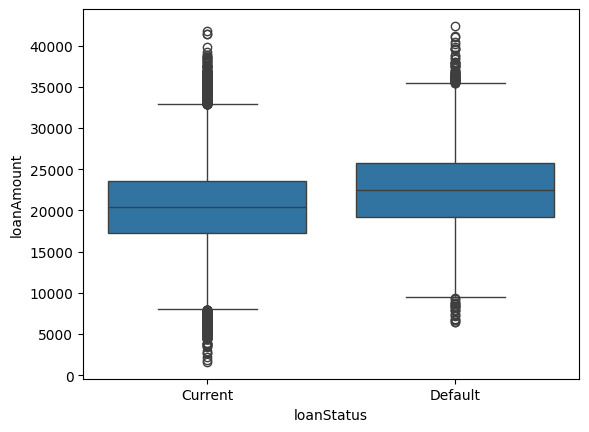

In [26]:
sns.boxplot(x="loanStatus", y="loanAmount", data=df)
plt.show()

Since the feature has many outliers so median is better in this case

In [27]:
df['loanAmount'] = df['loanAmount'].fillna(df['loanAmount'].median())

In [28]:
df['loanAmount'].isna().sum()

0

Imputing term attribute

In [29]:
df['term'].unique()

array(['60 months', '48 months', '36 months', None], dtype=object)

In [30]:
mode_term = df['term'].mode()[0]
df['term'] = df['term'].fillna(mode_term)

In [31]:
df['term'].isna().sum()

0

Imputing numOpenCreditLines

In [32]:
df['numOpenCreditLines'].unique()

array([ 9.,  7.,  5., 19., 15., 12., 11., 14.,  8., 25.,  2., 10., nan,
       13., 18.,  4., 17.,  6., 16., 21.,  3., 20., 23., 26., 22.,  1.,
       28., 24., 27., 29.])

In [33]:
df['numOpenCreditLines'].isna().sum()

967

In [34]:
mode_openLines = df['numOpenCreditLines'].mode()[0]
print(mode_openLines)

10.0


In [35]:
df['numOpenCreditLines'] = df['numOpenCreditLines'].fillna(mode_openLines)
df['numOpenCreditLines'].isna().sum()

0

In [36]:
df.isna().sum()

loanId                      0
memberId                    0
date                        0
purpose                     0
isJointApplication          0
loanAmount                  0
term                        0
interestRate                0
monthlyPayment              0
grade                       0
loanStatus                  0
residentialState            0
yearsEmployment             0
homeOwnership               0
annualIncome                0
incomeVerified              0
dtiRatio                    0
lengthCreditHistory         0
numTotalCreditLines         0
numOpenCreditLines          0
numOpenCreditLines1Year     0
revolvingBalance            0
revolvingUtilizationRate    0
numDerogatoryRec            0
numDelinquency2Years        0
numChargeoff1year           0
numInquiries6Mon            0
dtype: int64

In [ ]:
df.drop(['loanId', 'memberId'], axis=1, inplace=True)

KeyError: "['loanId', 'memberId'] not found in axis"

In [41]:
df.head()

,date,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,loanStatus,residentialState,...,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,numOpenCreditLines1Year,revolvingBalance,revolvingUtilizationRate,numDerogatoryRec,numDelinquency2Years,numChargeoff1year,numInquiries6Mon
0,12/10/2014,debtconsolidation,0.0,25190.0,60 months,6.25,490,E3,Current,NM,...,6,11,9.0,6,14301,49.02,0,19,10,0
1,9/15/2014,debtconsolidation,0.0,21189.0,60 months,10.49,455,B3,Current,WA,...,22,8,7.0,4,18262,72.40,1,0,0,0
2,9/11/2014,debtconsolidation,0.0,29908.0,60 months,9.11,622,B2,Current,MS,...,5,8,5.0,5,10799,66.27,0,1,1,0
3,4/22/2016,homeimprovement,0.0,13053.0,48 months,11.89,343,B3,Current,TX,...,12,14,7.0,3,15272,61.05,1,0,0,3
4,2/3/2016,debtconsolidation,0.0,24613.0,60 months,15.13,587,A3,Current,MA,...,4,21,19.0,10,19316,56.39,2,14,7,1


In [43]:
df.drop('date', axis = 1, inplace= True)

In [44]:
df.head()

,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,loanStatus,residentialState,yearsEmployment,...,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,numOpenCreditLines1Year,revolvingBalance,revolvingUtilizationRate,numDerogatoryRec,numDelinquency2Years,numChargeoff1year,numInquiries6Mon
0,debtconsolidation,0.0,25190.0,60 months,6.25,490,E3,Current,NM,10+ years,...,6,11,9.0,6,14301,49.02,0,19,10,0
1,debtconsolidation,0.0,21189.0,60 months,10.49,455,B3,Current,WA,2-5 years,...,22,8,7.0,4,18262,72.40,1,0,0,0
2,debtconsolidation,0.0,29908.0,60 months,9.11,622,B2,Current,MS,< 1 year,...,5,8,5.0,5,10799,66.27,0,1,1,0
3,homeimprovement,0.0,13053.0,48 months,11.89,343,B3,Current,TX,6-9 years,...,12,14,7.0,3,15272,61.05,1,0,0,3
4,debtconsolidation,0.0,24613.0,60 months,15.13,587,A3,Current,MA,2-5 years,...,4,21,19.0,10,19316,56.39,2,14,7,1


In [47]:
df.to_sql('preprocessed_data', conn, if_exists="replace", index=False)

100000

In [48]:
import sqlite3

conn = sqlite3.connect("D:\jai\Python-Workspace\Credit-Path-AI\database\creditpathai.db")
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

tables = cursor.fetchall()

for table in tables:
    print(table[0])

conn.close()

loans
borrowers
preprocessed_data
